# Dominasi Komoditas dan Inersia Pasar: Analisis Dinamis Determinan IHSG Menggunakan Partial Adjustment Model (PAM) Periode 2020-2025

Dea Kayla Putri Darusman / 3323600005

Project: Ekonometrika Terapan

## Import Library

In [86]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Download Data from Yahoo Finance

In [ ]:
tickers = ['^JKSE', 'IDR=X', 'BBRI.JK', 'TLKM.JK']
data = yf.download(tickers, start="2020-11-01", end="2025-11-01", interval="1mo", threads=False, auto_adjust=False)

try:
    df_final = data['Adj Close']
except KeyError:
    df_final = data.xs('Adj Close', level=0, axis=1)

df_final.columns.name = None 
df_final = df_final.rename(columns={
    '^JKSE': 'IHSG',
    'IDR=X': 'Kurs_Rupiah',
    'BBRI.JK': 'Saham_BUMN_BRI',
    'TLKM.JK': 'Saham_BUMN_Telkom'
})

df_final

[*********************100%***********************]  4 of 4 completed


,Saham_BUMN_BRI,Kurs_Rupiah,Saham_BUMN_Telkom,IHSG
Date,,,,
2020-11-01,2853.118164,14061.644531,2486.858398,5612.415039
2020-12-01,2908.924561,13832.559570,2548.452393,5979.073242
2021-01-01,2915.900635,14023.000000,2394.467529,5862.352051
2021-02-01,3285.620361,14332.400391,2687.039062,6241.795898
2021-03-01,3069.369385,14605.000000,2633.144531,5985.521973
2021-04-01,2825.215088,14439.700195,2463.760986,5995.616211
2021-05-01,3043.375732,14278.000000,2648.542969,5947.462891
2021-06-01,2814.765137,14629.099609,2425.264648,5985.488770
2021-07-01,2650.451660,14419.700195,2620.341797,6070.039062


## Transformasi Logaritma (Ln)

In [88]:
df_model = np.log(df_final)
df_model.columns = ['Ln_' + col for col in df_model.columns]
df_model.head()

,Ln_Saham_BUMN_BRI,Ln_Kurs_Rupiah,Ln_Saham_BUMN_Telkom,Ln_IHSG
Date,,,,
2020-11-01,7.956168,9.551206,7.818776,8.632736
2020-12-01,7.975539,9.534780,7.843242,8.696021
2021-01-01,7.977934,9.548454,7.780916,8.676306
2021-02-01,8.097311,9.570278,7.896195,8.739023
2021-03-01,8.029227,9.589119,7.875934,8.697099


## Create Lag Y (Y t-1)

In [89]:
df_model['Ln_IHSG_Lag1'] = df_model['Ln_IHSG'].shift(1)
df_model = df_model.dropna()
df_model.head()

,Ln_Saham_BUMN_BRI,Ln_Kurs_Rupiah,Ln_Saham_BUMN_Telkom,Ln_IHSG,Ln_IHSG_Lag1
Date,,,,,
2020-12-01,7.975539,9.534780,7.843242,8.696021,8.632736
2021-01-01,7.977934,9.548454,7.780916,8.676306,8.696021
2021-02-01,8.097311,9.570278,7.896195,8.739023,8.676306
2021-03-01,8.029227,9.589119,7.875934,8.697099,8.739023
2021-04-01,7.946340,9.577737,7.809444,8.698784,8.697099


## Regression Model

In [90]:
target_vars = [
    'Ln_Kurs_Rupiah', 
    'Ln_Saham_BUMN_BRI', 
    'Ln_Saham_BUMN_Telkom', 
    'Ln_IHSG_Lag1' 
]

X = df_model[target_vars]
Y = df_model['Ln_IHSG']
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags':1})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Ln_IHSG   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     89.22
Date:                Fri, 28 Nov 2025   Prob (F-statistic):           3.91e-23
Time:                        13:38:15   Log-Likelihood:                 124.64
No. Observations:                  59   AIC:                            -239.3
Df Residuals:                      54   BIC:                            -228.9
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.7080 

## INTERPRETASI UJI F & UJI t

In [91]:
print(f"Nilai F-Statistic : {model.fvalue:.4f}")
print(f"Prob (F-Statistic): {model.f_pvalue:.4e}")

print("\nSignifikansi Parsial (Uji t):")
print(model.pvalues < 0.05)

Nilai F-Statistic : 89.2198
Prob (F-Statistic): 3.9143e-23

Signifikansi Parsial (Uji t):
const                   False
Ln_Kurs_Rupiah          False
Ln_Saham_BUMN_BRI       False
Ln_Saham_BUMN_Telkom     True
Ln_IHSG_Lag1             True
dtype: bool


## Transformation to Distribution Lag

In [92]:
lambda_val = model.params['Ln_IHSG_Lag1']
print(f"Nilai λ (Lambda/Inersia): {lambda_val:.4f}")

for var in ['Ln_Kurs_Rupiah', 'Ln_Saham_BUMN_BRI', 'Ln_Saham_BUMN_Telkom']:
    beta_0 = model.params[var] 
    print(f"\n--- Distribusi Lag untuk {var} ---")

    total_impact = 0
    for k in range(6): 
        beta_k = beta_0 * (lambda_val ** k)
        total_impact += beta_k
        print(f"   Periode t-{k}: {beta_k:.6f}")

    long_run = beta_0 / (1 - lambda_val)
    print(f"   Total Dampak Jangka Panjang (Long Run): {long_run:.4f}")

Nilai λ (Lambda/Inersia): 0.6422

--- Distribusi Lag untuk Ln_Kurs_Rupiah ---
   Periode t-0: 0.278862
   Periode t-1: 0.179074
   Periode t-2: 0.114994
   Periode t-3: 0.073845
   Periode t-4: 0.047420
   Periode t-5: 0.030451
   Total Dampak Jangka Panjang (Long Run): 0.7793

--- Distribusi Lag untuk Ln_Saham_BUMN_BRI ---
   Periode t-0: 0.041273
   Periode t-1: 0.026504
   Periode t-2: 0.017020
   Periode t-3: 0.010929
   Periode t-4: 0.007018
   Periode t-5: 0.004507
   Total Dampak Jangka Panjang (Long Run): 0.1153

--- Distribusi Lag untuk Ln_Saham_BUMN_Telkom ---
   Periode t-0: 0.105753
   Periode t-1: 0.067911
   Periode t-2: 0.043610
   Periode t-3: 0.028004
   Periode t-4: 0.017983
   Periode t-5: 0.011548
   Total Dampak Jangka Panjang (Long Run): 0.2955


## SHORT TERM VS LONG TERM ANALYSIS

In [93]:
lambda_coef = model.params['Ln_IHSG_Lag1']
delta = 1 - lambda_coef  

print(f"Koefisien Lag Y (λ)     : {lambda_coef:.4f}")
print(f"Speed of Adjustment (δ) : {delta:.4f}")
print(f"Interpretasi: Pasar mengoreksi {delta*100:.1f}% ketidakseimbangan setiap bulannya.")

print(f"{'\nVARIABEL':<25}  | {'SHORT RUN (β)':<15} | {'LONG RUN (β/δ)':<15}")
target_x = ['Ln_Kurs_Rupiah', 'Ln_Saham_BUMN_BRI', 'Ln_Saham_BUMN_Telkom']

for var in target_x:
    beta_short = model.params[var]
    beta_long = beta_short / delta
    sig = "*" if model.pvalues[var] < 0.1 else ""
    print(f"{var:<25} | {beta_short:.4f} {sig:<5}    | {beta_long:.4f}")

Koefisien Lag Y (λ)     : 0.6422
Speed of Adjustment (δ) : 0.3578
Interpretasi: Pasar mengoreksi 35.8% ketidakseimbangan setiap bulannya.

VARIABEL                  | SHORT RUN (β)   | LONG RUN (β/δ) 
Ln_Kurs_Rupiah            | 0.2789 *        | 0.7793
Ln_Saham_BUMN_BRI         | 0.0413          | 0.1153
Ln_Saham_BUMN_Telkom      | 0.1058 *        | 0.2955


## Classic Assumption Test

In [94]:
name = ['Jarque-Bera', 'Chi^2 two-tail prob', 'Skew', 'Kurtosis']
test = sms.jarque_bera(model.resid)
print(f"Normalitas (Jarque-Bera): P-Value {test[1]:.4f} -> {'DISTRIBUSI NORMAL' if test[1]>0.05 else 'TIDAK NORMAL'}")

Normalitas (Jarque-Bera): P-Value 0.1532 -> DISTRIBUSI NORMAL


In [95]:
bg_test = sms.acorr_breusch_godfrey(model, nlags=1)
print(f"Autokorelasi (BG Test)  : P-Value {bg_test[1]:.4f}") 

Autokorelasi (BG Test)  : P-Value 0.1152


In [96]:
bp_test = sms.het_breuschpagan(model.resid, model.model.exog)
print(f"Heteroskedastisitas (BP): P-Value {bp_test[1]:.4f} -> {'HOMOSKEDASTIS' if bp_test[1]>0.05 else 'HETEROSKEDASTIS'}")

Heteroskedastisitas (BP): P-Value 0.0801 -> HOMOSKEDASTIS


In [97]:
print("Multikolinearitas (VIF):")
vif_data = pd.DataFrame()
vif_data["Variabel"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

Multikolinearitas (VIF):
               Variabel           VIF
0                 const  74295.452829
1        Ln_Kurs_Rupiah      3.382569
2     Ln_Saham_BUMN_BRI      2.258919
3  Ln_Saham_BUMN_Telkom      2.259376
4          Ln_IHSG_Lag1      2.985928


## Visualization

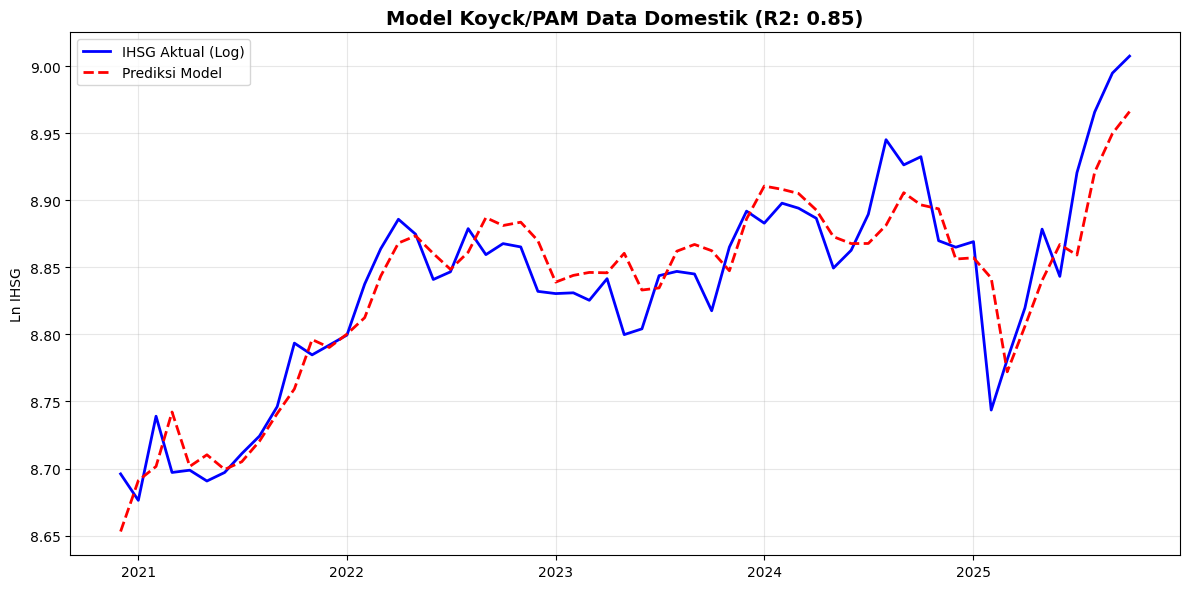

In [98]:
dates = pd.to_datetime(Y.index)
plt.figure(figsize=(12, 6))
plt.plot(dates, Y, label='IHSG Aktual (Log)', color='blue', linewidth=2)
plt.plot(dates, model.fittedvalues, label='Prediksi Model', color='red', linestyle='--', linewidth=2)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title(f'Model Koyck/PAM Data Domestik (R2: {model.rsquared:.2f})', fontsize=14, fontweight='bold')
plt.ylabel('Ln IHSG')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()